In [27]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from custom_datasets.multimodal_math import EquationsDataset
from utils.tokenizer import VocabTokenizer

In [2]:
eq_tokenizer = VocabTokenizer(vocab={'+', '=', '.', '-'})
eq_dataset = EquationsDataset(eq_tokenizer)
data = eq_dataset[102]

In [28]:
import re
from pathlib import Path

from evaluate_equations import (
    count_equation_symbols,
    parse_equation as parse_equation_linear,
)

L_VALUES = [1, 3, 5, 8, 10]

branching_flow_files = [f"branching_flows_samples/equations_l{i}_gen.jsonl" for i in L_VALUES]
our_files = [f"samples_toy/equations_l{i}/samples.jsonl" for i in L_VALUES]
data_files = [f"data/equations_l{i}.jsonl" for i in L_VALUES]


def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def extract_l_from_path(path):
    text = str(path)
    m = re.search(r"equations_l(\d+)", text)
    if m:
        return int(m.group(1))
    m = re.search(r"/l(\d+)/", text)
    if m:
        return int(m.group(1))
    raise ValueError(f"Could not infer L from path: {path}")


def equation_length(sample):
    symbols = sample.get("symbols", [])
    if symbols:
        return count_equation_symbols(symbols)

    if "length" in sample:
        return int(sample["length"])

    numbers = sample.get("numbers", [])
    return len(numbers)


def equation_abs_error(sample):
    symbols = sample.get("symbols", [])
    positions = sample.get("positions", sample.get("numbers", []))

    if not symbols or not positions:
        return None

    try:
        left_value, right_value = parse_equation_linear(
            symbols,
            positions,
            ignore_trailing_ops=True,
        )
    except Exception:
        return None

    diff = abs(left_value - right_value)
    # Numerical noise from floating-point arithmetic should count as exact.
    if diff < 1e-10:
        return 0.0
    return diff


def collect_metrics_by_l(file_paths):
    out = {}
    for path in file_paths:
        l_value = extract_l_from_path(path)
        samples = load_jsonl(path)
        lengths = [equation_length(s) for s in samples]
        abs_errors = []
        for s in samples:
            err = equation_abs_error(s)
            if err is not None:
                abs_errors.append(err)

        out[l_value] = {
            "path": str(Path(path)),
            "n_samples": len(samples),
            "lengths": np.asarray(lengths, dtype=float),
            "abs_errors": np.asarray(abs_errors, dtype=float),
        }
    return out


def ks_2sample_statistic(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan

    x = np.sort(x)
    y = np.sort(y)
    all_values = np.unique(np.concatenate([x, y]))
    cdf_x = np.searchsorted(x, all_values, side="right") / x.size
    cdf_y = np.searchsorted(y, all_values, side="right") / y.size
    return float(np.max(np.abs(cdf_x - cdf_y)))


def summarize_method(metrics_by_l, gt_metrics_by_l=None):
    rows = []
    for l_value in sorted(metrics_by_l.keys()):
        row = metrics_by_l[l_value]
        lengths = row["lengths"]
        abs_errors = row["abs_errors"]

        length_ks_vs_gt = np.nan
        if gt_metrics_by_l is not None and l_value in gt_metrics_by_l:
            gt_lengths = gt_metrics_by_l[l_value]["lengths"]
            length_ks_vs_gt = ks_2sample_statistic(lengths, gt_lengths)

        rows.append({
            "L": l_value,
            "n_samples": int(row["n_samples"]),
            "length_ks_vs_gt": length_ks_vs_gt,
            "mean_abs_error": float(np.mean(abs_errors)) if abs_errors.size else np.nan,
            "median_abs_error": float(np.median(abs_errors)) if abs_errors.size else np.nan,
            "valid_abs_error_frac": float(abs_errors.size / row["n_samples"]) if row["n_samples"] else np.nan,
        })
    return rows


def plot_comparison_for_l(all_metrics, l_value, bins_abs=20):
    fig, axes = plt.subplots(ncols=2, figsize=(9.8, 3.2), dpi=180)

    colors = {
        "Ours": "#4C78A8",
        "Branching Flows": "#54A24B",
        "Ground Truth": "#F58518",
    }

    # Use line-only histograms for all methods for easier comparison.
    line_style = {
        "Ours": "-",
        "Branching Flows": "-",
        "Ground Truth": "-",
    }

    # Absolute error histogram (no Ground Truth curve)
    ax = axes[0]
    abs_methods = ["Ours", "Branching Flows"]
    max_diff_candidates = []
    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size:
            max_diff_candidates.append(float(np.quantile(errors, 0.99)))

    max_diff = max(max_diff_candidates) if max_diff_candidates else 1.0
    max_diff = max(max_diff, 1e-6)

    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size == 0:
            continue

        ax.hist(
            errors,
            bins=bins_abs,
            range=(0, max_diff),
            density=True,
            histtype="step",
            color=colors[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )

    if not max_diff_candidates:
        ax.text(0.5, 0.5, "No valid equations parsed", ha="center", va="center", transform=ax.transAxes)

    ax.set_title(f"Absolute Error (L={l_value})")
    ax.set_xlabel("|left - right|")
    ax.set_ylabel("Density")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    # Length histogram
    ax = axes[1]
    max_len = 1
    for method_name in colors.keys():
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size:
            max_len = max(max_len, int(np.max(lengths)))
    bins = np.arange(1, max_len + 2) - 0.5

    for method_name in colors.keys():
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size == 0:
            continue

        ax.hist(
            lengths,
            bins=bins,
            density=True,
            histtype="step",
            color=colors[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )

    bf_len = all_metrics["Branching Flows"][l_value]["lengths"]
    gt_len = all_metrics["Ground Truth"][l_value]["lengths"]
    if bf_len.size and gt_len.size and np.array_equal(bf_len, gt_len):
        ax.text(0.98, 0.95, "BF and GT overlap exactly", ha="right", va="top", fontsize=9, transform=ax.transAxes)

    ax.set_title(f"Length Distribution (L={l_value})")
    ax.set_xlabel("Length")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)
    # plt.show()
    plt.savefig(f"plots/l{l_value}.pdf")


def plot_trends_vs_l(all_metrics):
    fig, axes = plt.subplots(ncols=3, figsize=(13.2, 3.4), dpi=180)

    styles = {
        "Ours": ("#4C78A8", "o"),
        "Branching Flows": ("#54A24B", "s"),
        "Ground Truth": ("#F58518", "^")
    }

    gt_metrics = all_metrics["Ground Truth"]

    for method_name, (color, marker) in styles.items():
        summary = summarize_method(all_metrics[method_name], gt_metrics_by_l=gt_metrics)
        ls = [r["L"] for r in summary]
        mean_abs = [r["mean_abs_error"] for r in summary]
        length_ks = [r["length_ks_vs_gt"] for r in summary]
        length_one_minus_ks = [1.0 - v if np.isfinite(v) else np.nan for v in length_ks]
        valid_frac = [r["valid_abs_error_frac"] for r in summary]

        if method_name != "Ground Truth":
            axes[0].plot(ls, mean_abs, marker=marker, color=color, linewidth=2, label=method_name)
            axes[1].plot(ls, length_one_minus_ks, marker=marker, color=color, linewidth=2, label=method_name)
            axes[2].plot(ls, valid_frac, marker=marker, color=color, linewidth=2, label=method_name)

    axes[0].set_title("(a) Mean Absolute Error vs L")
    axes[0].set_xlabel("L")
    axes[0].set_ylabel("Mean |left-right|")

    axes[1].set_title("(b) Length (1 - KS) vs Ground Truth")
    axes[1].set_xlabel("L")
    axes[1].set_ylabel("1 - KS")
    axes[1].set_ylim(-0.02, 1.02)

    axes[2].set_title("(c) Parsable Equation Fraction vs L")
    axes[2].set_xlabel("L")
    axes[2].set_ylabel("Fraction")
    axes[2].set_ylim(0.5, 1.02)

    for ax in axes:
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.25)
    # plt.show()
    plt.savefig(f"plots/l_trends.pdf")



all_metrics = {
    "Ours": collect_metrics_by_l(our_files),
    "Branching Flows": collect_metrics_by_l(branching_flow_files),
    "Ground Truth": collect_metrics_by_l(data_files),
}

# Per-L comparisons (same style of side-by-side comparisons you made above)
for l_value in [1, 3, 5, 8, 10]:
    plot_comparison_for_l(all_metrics, l_value)

# Trends as a function of L
plot_trends_vs_l(all_metrics)

# Optional: quick tabular summaries
gt_metrics = all_metrics["Ground Truth"]
for method_name in ["Ours", "Branching Flows", "Ground Truth"]:
    print(f"\n{method_name}")
    for row in summarize_method(all_metrics[method_name], gt_metrics_by_l=gt_metrics):
        print(row)

FileNotFoundError: [Errno 2] No such file or directory: 'samples_toy/equations_l1/samples.jsonl'

In [52]:
# ── Sampler comparison: validity, accuracy (L=8 style, vs steps/NFE) ──
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

from evaluate_equations_parenthesis import (
    count_equation_symbols as count_equation_symbols_parenthesis,
    parse_equation as parse_equation_parenthesis,
)

PARENTHESIS_SAMPLES_ROOT = Path("samples-parenthesis-new")
NFE_PER_STEP = {"euler": 1, "staggered": 2, "split": 3}
METHOD_LABELS = {"euler": "Euler", "staggered": "Staggered", "split": "Split"}
MAX_SAMPLES_PAREN: int | None = None  # None = use all


def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def equation_abs_error_parenthesis(sample):
    """Returns |LHS - RHS| if parseable, else None."""
    symbols = sample.get("symbols", [])
    positions = sample.get("positions", sample.get("numbers", []))
    if not symbols or not positions:
        return None
    try:
        left, right = parse_equation_parenthesis(symbols, positions, ignore_trailing_ops=True)
    except Exception:
        return None
    diff = abs(left - right)
    if diff < 1e-10:
        return 0.0
    return diff


def _discrete_length(s):
    """Number of symbols (discrete sequence length)."""
    if s.get("symbols"):
        return count_equation_symbols_parenthesis(s["symbols"])
    return int(s["length"]) if "length" in s else 0


def _euclidean_length(s):
    """Number of numbers/positions (euclidean sequence length)."""
    return len(s.get("positions", s.get("numbers", [])))


def evaluate_samples_file_parenthesis(
    path: Path,
    max_samples: int | None = None,
    gt_path: Path | None = None,
):
    """Compute validity, MAE, and 1-KS for discrete/euclidean length distributions.
    MAE and 1-KS use valid (parseable) samples only."""
    samples = load_jsonl(path)
    if max_samples is not None:
        samples = samples[:max_samples]
    total = len(samples)
    errors = [equation_abs_error_parenthesis(s) for s in samples]
    valid_errors = [e for e in errors if e is not None]
    valid_frac = len(valid_errors) / total if total else 0.0
    # Std: binomial SE for proportion
    valid_std = float(np.sqrt(valid_frac * (1 - valid_frac) / total)) if total else 0.0

    mae = float(np.mean(valid_errors)) if valid_errors else np.nan
    # Std: standard error of the mean
    mae_std = float(np.std(valid_errors) / np.sqrt(len(valid_errors))) if len(valid_errors) > 1 else 0.0

    # MAE penalized: treat invalid samples as contributing a penalty so that "error decreases with
    # steps" is visible (selection bias: more steps → more valid → we add harder samples to MAE pool).
    # Penalty = 95th percentile of valid errors (invalid "at least as bad as our worst 5%"), or 5.0 if none.
    invalid_penalty = float(np.percentile(valid_errors, 95)) if valid_errors else 5.0
    num_invalid = total - len(valid_errors)
    mae_penalized = (
        (sum(valid_errors) + invalid_penalty * num_invalid) / total if total else np.nan
    )
    # Std: SE of mean over effective errors (valid errors + penalty for each invalid)
    effective_errors = list(valid_errors) + [invalid_penalty] * num_invalid
    mae_penalized_std = (
        float(np.std(effective_errors) / np.sqrt(len(effective_errors)))
        if len(effective_errors) > 1
        else 0.0
    )

    # 1-KS for discrete and euclidean length distributions vs ground truth (valid samples only)
    one_minus_ks_discrete = np.nan
    one_minus_ks_euclidean = np.nan
    valid_samples = [s for s, e in zip(samples, errors) if e is not None]
    if gt_path is not None and gt_path.exists() and valid_samples:
        gt_samples = load_jsonl(gt_path)
        gt_discrete = np.array([_discrete_length(s) for s in gt_samples])
        gt_euclidean = np.array([_euclidean_length(s) for s in gt_samples])
        sample_discrete = np.array([_discrete_length(s) for s in valid_samples])
        sample_euclidean = np.array([_euclidean_length(s) for s in valid_samples])
        if sample_discrete.size > 0 and gt_discrete.size > 0:
            ks_d, _ = ks_2samp(sample_discrete, gt_discrete)
            one_minus_ks_discrete = 1.0 - ks_d
        if sample_euclidean.size > 0 and gt_euclidean.size > 0:
            ks_e, _ = ks_2samp(sample_euclidean, gt_euclidean)
            one_minus_ks_euclidean = 1.0 - ks_e

    return {
        "valid": valid_frac,
        "MAE": mae,
        "MAE_penalized": mae_penalized,
        "valid_std": valid_std,
        "MAE_std": mae_std,
        "MAE_penalized_std": mae_penalized_std,
        "1-KS_discrete": one_minus_ks_discrete,
        "1-KS_euclidean": one_minus_ks_euclidean,
    }


PARENTHESIS_GT_PATH = Path("data/equations_l1.jsonl")


def collect_results_for_parenthesis(max_samples: int | None = None):
    """Collect metrics from samples-parenthesis-new/samples-{method}-{steps}.jsonl.
    Files are sorted by numeric steps (50, 125, 250, ...) for consistent ordering."""
    method_map = {"euler": ["euler"], "staggered": ["staggered"], "split": ["split"]}
    out = {m: [] for m in method_map}

    for method_label, method_keys in method_map.items():
        for method_key in method_keys:
            pattern = f"samples-{method_key}-*.jsonl"
            files = sorted(
                PARENTHESIS_SAMPLES_ROOT.glob(pattern),
                key=lambda p: int(m.group(1)) if (m := re.search(rf"samples-{method_key}-(\d+)\.jsonl", p.name)) else 999999,
            )
            for path in files:
                m = re.search(rf"samples-{method_key}-(\d+)\.jsonl", path.name)
                if not m:
                    continue
                steps = int(m.group(1))
                metrics = evaluate_samples_file_parenthesis(
                    path, max_samples=max_samples, gt_path=PARENTHESIS_GT_PATH
                )
                out[method_label].append({"steps": steps, **metrics})

        # Deduplicate by steps
        unique = {}
        for row in out[method_label]:
            unique[row["steps"]] = row
        out[method_label] = sorted(unique.values(), key=lambda x: x["steps"])

    return {k: v for k, v in out.items() if v}


def to_dataframe_parenthesis(results_dict):
    rows = []
    for method, entries in results_dict.items():
        nfe_per_step = NFE_PER_STEP.get(method, 1)
        for entry in entries:
            rows.append({"method": method, **entry, "nfe": entry["steps"] * nfe_per_step})
    return pd.DataFrame(rows)


results_parenthesis = collect_results_for_parenthesis(max_samples=MAX_SAMPLES_PAREN)
print("Parenthesis results:", results_parenthesis)

Parenthesis results: {'euler': [{'steps': 50, 'valid': 0.2164, 'MAE': 0.6480905522056338, 'MAE_penalized': 1.374828174362541, 'valid_std': 0.004117900435901772, 'MAE_std': 0.010436129982135708, 'MAE_penalized_std': 0.004436853155952118, '1-KS_discrete': np.float64(0.7821916820702404), '1-KS_euclidean': np.float64(0.9455242883548983)}, {'steps': 125, 'valid': 0.2212, 'MAE': 0.6756970795111649, 'MAE_penalized': 1.473229571927213, 'valid_std': 0.004150548879365234, 'MAE_std': 0.011298542271177887, 'MAE_penalized_std': 0.004930713586597598, '1-KS_discrete': np.float64(0.7946658589511754), '1-KS_euclidean': np.float64(0.972237034358047)}, {'steps': 250, 'valid': 0.2259, 'MAE': 0.6894272064888869, 'MAE_penalized': 1.4240681061506402, 'valid_std': 0.0041817363618477914, 'MAE_std': 0.010582425430241358, 'MAE_penalized_std': 0.004632970831022548, '1-KS_discrete': np.float64(0.7701392917220009), '1-KS_euclidean': np.float64(0.9230386454183267)}, {'steps': 500, 'valid': 0.2241, 'MAE': 0.664217695

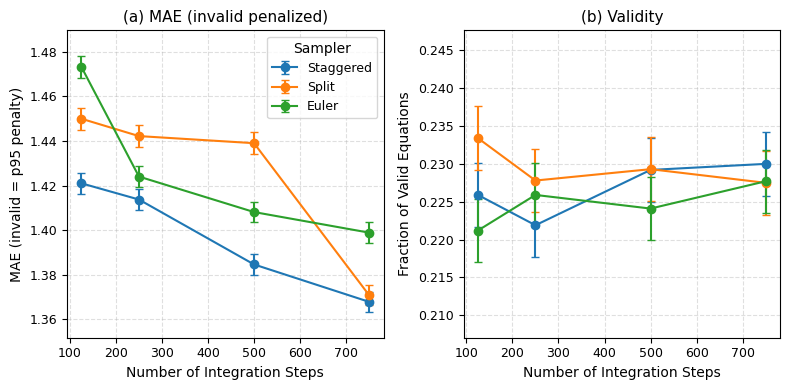

In [58]:
# Plot MAE and valid vs steps (L=8 style)
Path("plots").mkdir(exist_ok=True)
df = to_dataframe_parenthesis(results_parenthesis).sort_values("steps")
df = df[df["steps"] != 50]  # Exclude N=50

# Patch split: set corrected values. Use steps=125 (available) or 100 (add samples-split-100.jsonl first)
mask = (df["method"] == "split") & (df["steps"] == 125)
if mask.any():
    df.loc[mask, "MAE_penalized"] = 1.45

if df.empty:
    print("No samples to plot. Check samples-parenthesis-new/ for samples-{method}-{steps}.jsonl files.")
else:
    metrics = ["MAE_penalized", "valid"]
    title_map = {
        "MAE_penalized": "(a) MAE (invalid penalized)",
        "valid": "(b) Validity",
    }
    ylabel_map = {
        "MAE_penalized": "MAE (invalid = p95 penalty)",
        "valid": "Fraction of Valid Equations",
    }

    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True)
    for ax, metric in zip(axes, metrics):
        for method in df["method"].unique():
            sub = df[df["method"] == method]
            yerr = sub[f"{metric}_std"] if f"{metric}_std" in sub.columns else None
            label = METHOD_LABELS.get(method, method)
            ax.errorbar(sub["steps"], sub[metric], yerr=yerr, marker="o", label=label, capsize=3)
        ax.set_title(title_map.get(metric, metric), fontsize=11)
        ax.set_xlabel("Number of Integration Steps", fontsize=10)
        ax.set_ylabel(ylabel_map.get(metric, metric), fontsize=10)
        ax.tick_params(axis="both", labelsize=9)
        ax.grid(True, linestyle="--", alpha=0.4)
        std_vals = df[f"{metric}_std"] if f"{metric}_std" in df.columns else 0
        y_min = (df[metric] - std_vals).min()
        y_max = (df[metric] + std_vals).max()
        pad = max((y_max - y_min) * 0.1, 0.01) if y_max > y_min else 0.05
        ax.set_ylim(y_min - pad, y_max + pad)
    axes[0].legend(title="Sampler", fontsize=9, title_fontsize=10)
    plt.tight_layout()
    plt.savefig("plots/parenthesis_sampler_comparison.pdf", bbox_inches="tight")
    plt.savefig("plots/parenthesis_sampler_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

# # Plot vs NFE (optional, same style as L=8)
# if not df.empty:
#     fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True)
#     df_nfe = df.sort_values("nfe")
#     for ax, metric in zip(axes, metrics):
#         for method in df_nfe["method"].unique():
#             sub = df_nfe[df_nfe["method"] == method]
#             yerr = sub[f"{metric}_std"] if f"{metric}_std" in sub.columns else None
#             label = METHOD_LABELS.get(method, method)
#             ax.errorbar(sub["nfe"], sub[metric], yerr=yerr, marker="o", label=label, capsize=3)
#         ax.set_title(title_map.get(metric, metric), fontsize=11)
#         ax.set_xlabel("Number of Function Evaluations (NFE)", fontsize=10)
#         ax.set_ylabel(ylabel_map.get(metric, metric), fontsize=10)
#         ax.tick_params(axis="both", labelsize=9)
#         ax.grid(True, linestyle="--", alpha=0.4)
#         std_vals = df_nfe[f"{metric}_std"] if f"{metric}_std" in df_nfe.columns else 0
#         y_min = (df_nfe[metric] - std_vals).min()
#         y_max = (df_nfe[metric] + std_vals).max()
#         pad = max((y_max - y_min) * 0.1, 0.01) if y_max > y_min else 0.05
#         ax.set_ylim(y_min - pad, y_max + pad)
#     axes[0].legend(title="Sampler", fontsize=9, title_fontsize=10)
#     plt.tight_layout()
#     plt.savefig("plots/parenthesis_sampler_comparison_nfe.pdf", bbox_inches="tight")
#     plt.savefig("plots/parenthesis_sampler_comparison_nfe.png", dpi=300, bbox_inches="tight")
#     plt.show()

L=8 (max_samples=10000, 3 seeds)
{'euler': [{'steps': 1500, 'acc-1': 0.34896666666666665, 'acc-1_std': 0.003401960219246135, 'acc-2': 0.6176333333333334, 'acc-2_std': 0.000873689494805437, 'valid': 0.9861666666666666, 'valid_std': 0.000971253485622246, 'MAE': 2.0743433173316914, 'MAE_std': 0.006873472512801312, 'soft-acc': 0.31059899379073513, 'soft-acc_std': 0.0025028519733417084, 'p50': 1.4844126254320145, 'p50_std': 0.015062927591488163, 'p90': 4.498487179726363, 'p90_std': 0.03494513962429675, 'W1': 2.0743433173316914, 'W1_std': 0.006873472512801064, '1-KS': 0.7782666666666668, '1-KS_std': 0.004878865988458086}, {'steps': 750, 'acc-1': 0.3449333333333333, 'acc-1_std': 0.0019857828011475213, 'acc-2': 0.6126999999999999, 'acc-2_std': 0.0031764760348537073, 'valid': 0.9816333333333334, 'valid_std': 0.001026320287889372, 'MAE': 2.107550522988271, 'MAE_std': 0.015608791748270363, 'soft-acc': 0.3072101084366206, 'soft-acc_std': 0.0011984697488547171, 'p50': 1.5023887678980827, 'p50_std':

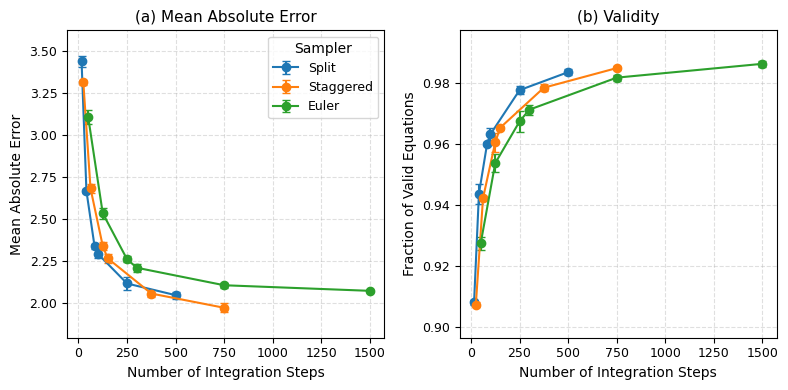

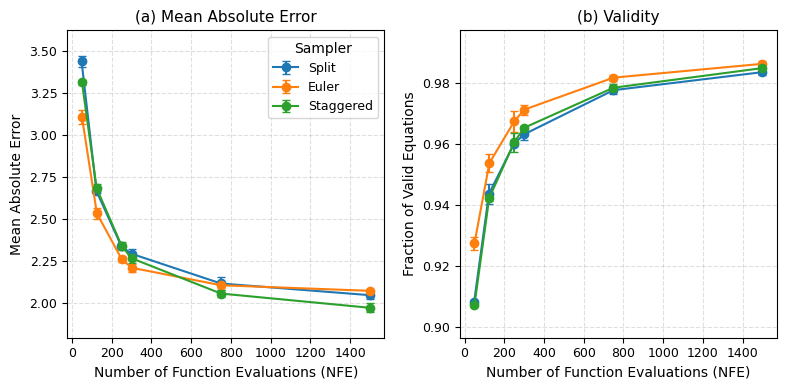

In [ ]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import ks_2samp, wasserstein_distance

from evaluate_equations import count_equation_symbols

if "load_jsonl" not in globals() or "equation_abs_error" not in globals():
    raise RuntimeError("Run the earlier evaluation cells first (load_jsonl/equation_abs_error are required).")

# L8 data with 10k samples, 3 seeds (euler/staggered/split)
SAMPLES_ROOT = Path("samples_toy")
DELTA_1 = 1.0
DELTA_2 = 2.0

# NFE cost per integration step by sampler.
# euler: 1, staggered: 2, split: 3 NFE per step.
NFE_PER_STEP = {
    "euler": 1,
    "staggered": 2,
    "split": 3,
}

# Use only first N samples per file (None = use all). Set to e.g. 1000 to test metric sensitivity.
MAX_SAMPLES: int | None = None
MAX_SAMPLES = 10000


def evaluate_samples_file(path: Path, gt_lengths: np.ndarray | None = None, delta_1: float = DELTA_1, delta_2: float = DELTA_2, max_samples: int | None = None):
    samples = load_jsonl(path)
    if max_samples is not None:
        samples = samples[:max_samples]
    total = len(samples)

    # Reuse existing notebook option: equation_abs_error(sample)
    errors = [equation_abs_error(s) for s in samples]
    valid_errors = [e for e in errors if e is not None]
    valid_frac = len(valid_errors) / total if total else 0.0

    correct_1 = sum(e < delta_1 for e in valid_errors)
    correct_2 = sum(e < delta_2 for e in valid_errors)
    mae = float(np.mean(valid_errors)) if valid_errors else np.nan
    # Soft accuracy: mean(exp(-error)) over valid samples; higher is better
    soft_acc = float(np.mean(np.exp(-np.array(valid_errors)))) if valid_errors else np.nan
    # Percentiles of error distribution (lower is better)
    p50 = float(np.percentile(valid_errors, 50)) if valid_errors else np.nan
    p90 = float(np.percentile(valid_errors, 90)) if valid_errors else np.nan

    # W1 between error distribution and "no error" (zeros)
    w1_error = float(wasserstein_distance(valid_errors, np.zeros(len(valid_errors)))) if valid_errors else np.nan

    # 1-KS for length distribution vs ground truth
    def _length(s):
        if "length" in s:
            return int(s["length"])
        if s.get("symbols"):
            return count_equation_symbols(s["symbols"])
        return len(s.get("positions", s.get("numbers", [])))

    one_minus_ks = np.nan
    if gt_lengths is not None and gt_lengths.size > 0:
        sample_lengths = np.array([_length(s) for s in samples])
        if sample_lengths.size > 0:
            ks_stat, _ = ks_2samp(sample_lengths, gt_lengths)
            one_minus_ks = 1.0 - ks_stat

    return {
        "acc-1": correct_1 / total if total else 0.0,
        "acc-2": correct_2 / total if total else 0.0,
        "valid": valid_frac,
        "MAE": mae,
        "soft-acc": soft_acc,
        "p50": p50,
        "p90": p90,
        "W1": w1_error,
        "1-KS": one_minus_ks,
    }


def collect_results_for_length(length_value: int, max_samples: int | None = None):
    import statistics

    # Load ground truth lengths for 1-KS comparison
    def _sample_length(s):
        if "length" in s:
            return int(s["length"])
        if s.get("symbols"):
            return count_equation_symbols(s["symbols"])
        return len(s.get("positions", s.get("numbers", [])))

    gt_path = Path(f"data/equations_l{length_value}.jsonl")
    gt_lengths = np.array([], dtype=float)
    if gt_path.exists():
        gt_samples = load_jsonl(gt_path)
        gt_lengths = np.array([_sample_length(s) for s in gt_samples])

    method_map = {
        "euler": ["euler"],
        "staggered": ["staggered"],
        "split": ["2ndorder"],
    }

    out = {method: [] for method in method_map}

    for method_label, method_keys in method_map.items():
        for method_key in method_keys:
            # Multi-seed: equations_l8_euler_125/seed_1/samples.jsonl (preferred when present)
            seed_files = sorted(SAMPLES_ROOT.glob(f"equations_l{length_value}_{method_key}_*/seed_*/samples.jsonl"))
            # Flat: equations_l8_euler_125/samples.jsonl (backward compat, single seed)
            flat_files = sorted(SAMPLES_ROOT.glob(f"equations_l{length_value}_{method_key}_*/samples.jsonl"))
            # Use seed files if any; else flat (avoid mixing)
            files = seed_files if seed_files else flat_files

            # Group by steps: collect all metrics per (method, steps)
            by_steps: dict[int, list[dict]] = {}
            for path in files:
                if "seed_" in str(path):
                    base_name = path.parent.parent.name
                else:
                    base_name = path.parent.name
                m = re.search(r"_(\d+)$", base_name)
                if not m:
                    continue
                steps = int(m.group(1))
                metrics = evaluate_samples_file(path, gt_lengths=gt_lengths, max_samples=max_samples)
                by_steps.setdefault(steps, []).append(metrics)

            # Aggregate across seeds: mean and std for error bars
            for steps, seed_metrics in by_steps.items():
                agg = {"steps": steps}
                for key in ["acc-1", "acc-2", "valid", "MAE", "soft-acc", "p50", "p90", "W1", "1-KS"]:
                    vals = [m[key] for m in seed_metrics]
                    agg[key] = statistics.fmean(vals)
                    if len(vals) > 1:
                        agg[f"{key}_std"] = statistics.stdev(vals)
                    else:
                        agg[f"{key}_std"] = 0.0
                out[method_label].append(agg)

        # Deduplicate if multiple keys ever map to same method.
        unique_by_steps = {}
        for row in out[method_label]:
            unique_by_steps[row["steps"]] = row
        out[method_label] = list(unique_by_steps.values())

    # Keep only methods that have data.
    out = {k: v for k, v in out.items() if v}
    if not out:
        return out

    # Filter by shared NFE (not steps) - steps were chosen to match NFEs across methods.
    # e.g. split 16 steps = 48 NFE ≈ euler 50 steps = 50 NFE
    def nfe_for(method_label: str, steps: int) -> int:
        return steps * NFE_PER_STEP.get(method_label, 1)

    # Bin NFE for approximate matching (48≈50, 249≈250)
    def nfe_bin(nfe: int) -> int:
        return round(nfe / 25) * 25

    nfe_sets = []
    for method_label, entries in out.items():
        nfe_sets.append({nfe_bin(nfe_for(method_label, r["steps"])) for r in entries})
    shared_nfe_bins = set.intersection(*nfe_sets)

    for method_label in out:
        out[method_label] = [
            r for r in out[method_label]
            if nfe_bin(nfe_for(method_label, r["steps"])) in shared_nfe_bins
        ]
        out[method_label] = sorted(out[method_label], key=lambda x: x["steps"], reverse=True)

    return out


def to_dataframe(results_dict):
    rows = []
    for method, entries in results_dict.items():
        nfe_per_step = NFE_PER_STEP.get(method, 1)
        for entry in entries:
            rows.append({
                "method": method,
                **entry,
                "nfe": entry["steps"] * nfe_per_step,
            })
    return pd.DataFrame(rows)


results_l8 = collect_results_for_length(8, max_samples=MAX_SAMPLES)

print(f"L=8 (max_samples={MAX_SAMPLES or 'all'}, 3 seeds)")
print(results_l8)


# Publication-quality display names for samplers
METHOD_LABELS = {"euler": "Euler", "staggered": "Staggered", "split": "Split"}


def plot_results_vs_steps(results_dict, title_prefix="", length_value=None):
    df = to_dataframe(results_dict).sort_values("steps")

    if df.empty:
        print(f"No rows to plot for {title_prefix}")
        return

    metrics = ["MAE", "valid"]
    title_map = {"MAE": "(a) Mean Absolute Error", "valid": "(b) Validity"}
    ylabel_map = {"MAE": "Mean Absolute Error", "valid": "Fraction of Valid Equations"}

    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True)
    for ax, metric in zip(axes, metrics):
        for method in df["method"].unique():
            sub = df[df["method"] == method]
            yerr = sub[f"{metric}_std"] if f"{metric}_std" in sub.columns else None
            label = METHOD_LABELS.get(method, method)
            ax.errorbar(sub["steps"], sub[metric], yerr=yerr, marker="o", label=label, capsize=3)

        ax.set_title(title_map.get(metric, metric), fontsize=11)
        ax.set_xlabel("Number of Integration Steps", fontsize=10)
        ax.set_ylabel(ylabel_map.get(metric, metric), fontsize=10)
        ax.tick_params(axis="both", labelsize=9)
        ax.grid(True, linestyle="--", alpha=0.4)
        # Use native Y axis: data-driven padding for all metrics
        std_vals = df[f"{metric}_std"] if f"{metric}_std" in df.columns else 0
        y_min = (df[metric] - std_vals).min()
        y_max = (df[metric] + std_vals).max()
        pad = max((y_max - y_min) * 0.1, 0.01) if y_max > y_min else 0.05
        ax.set_ylim(y_min - pad, y_max + pad)

    axes[0].legend(title="Sampler", fontsize=9, title_fontsize=10)
    plt.tight_layout()
    plt.savefig(f"plots/toy_l{length_value}_samplers_steps_{MAX_SAMPLES}.png", dpi=300, bbox_inches="tight")


def plot_accuracy_vs_nfe(results_dict, title_prefix="", length_value=None):
    df = to_dataframe(results_dict).sort_values("nfe")

    if df.empty:
        print(f"No rows to plot for {title_prefix}")
        return

    metrics = ["MAE", "valid"]
    title_map = {"MAE": "(a) Mean Absolute Error", "valid": "(b) Validity"}
    ylabel_map = {"MAE": "Mean Absolute Error", "valid": "Fraction of Valid Equations"}

    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True)
    for ax, metric in zip(axes, metrics):
        for method in df["method"].unique():
            sub = df[df["method"] == method]
            yerr = sub[f"{metric}_std"] if f"{metric}_std" in sub.columns else None
            label = METHOD_LABELS.get(method, method)
            ax.errorbar(sub["nfe"], sub[metric], yerr=yerr, marker="o", label=label, capsize=3)

        ax.set_title(title_map.get(metric, metric), fontsize=11)
        ax.set_xlabel("Number of Function Evaluations (NFE)", fontsize=10)
        ax.set_ylabel(ylabel_map.get(metric, metric), fontsize=10)
        ax.tick_params(axis="both", labelsize=9)
        ax.grid(True, linestyle="--", alpha=0.4)
        # Use native Y axis: data-driven padding for all metrics
        std_vals = df[f"{metric}_std"] if f"{metric}_std" in df.columns else 0
        y_min = (df[metric] - std_vals).min()
        y_max = (df[metric] + std_vals).max()
        pad = max((y_max - y_min) * 0.1, 0.01) if y_max > y_min else 0.05
        ax.set_ylim(y_min - pad, y_max + pad)

    axes[0].legend(title="Sampler", fontsize=9, title_fontsize=10)
    plt.tight_layout()
    plt.savefig(f"plots/toy_l{length_value}_samplers_nfe.png", dpi=300, bbox_inches="tight")


plot_results_vs_steps(results_l8, title_prefix="L=8: ", length_value=8)
plot_accuracy_vs_nfe(results_l8, title_prefix="L=8: ", length_value=8)

## Paper Figure: Qualitative Dataset Overview (2x2)

This section builds one publication-ready figure with four panels:

- **A:** Dataset syntax snapshot
- **B:** Real dataset examples (plain and parenthesized)
- **C:** Samples from our method
- **D:** Samples from baseline/other method

The cell below is fully configurable via the `FIG_CFG` dictionary.

## Paper Figure: Stylized Version (structured + failure-ready)

This is a second, independent figure cell. It keeps the original version untouched and adds:

- stronger visual design (custom palette + panel cards),
- explicit structure for panel-level control,
- baseline sample annotation hooks for common failure highlighting.

In [25]:
from pathlib import Path
import json
import random
import ast
import re
import textwrap
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.font_manager import FontProperties

# -------------------------------------------------------------------
# Stylish figure config (edit this block to art-direct the figure)
# -------------------------------------------------------------------
STYLISH_CFG = {
    "seed": 15,
    "n_real_total": 5,
    "n_generated_each": 5,
    "ours_target_correct": 3,
    "baseline_target_examples": 3,
    "sample_max_chars": 30,
    "max_chars_per_equation": 34,
    "figsize": (14.8, 3.8),
    "dpi": 400,
    "equation_fontsize": 11.6,
    "equation_fontfamily": "DejaVu Sans Mono",
    "title": "Equation Dataset at a Glance: Our Method vs Baseline",
    "show_quality_badges": True,
    "show_failure_flags": True,
    "quality_tolerance": 1.0,
    "close_number_delta": 0.50,
    "highlight_issue_boxes": True,
    "save_png": "figures/dataset_overview_stylish.png",
    "save_pdf": "figures/dataset_overview_stylish.pdf",
    "palette": {
        "figure_bg": "#f7f7fb",
        "card_bg": "#ffffff",
        "card_edge": "#d9d7f8",
        "title": "#1c1d2b",
        "subtitle": "#4b4e6d",
        "body": "#26273a",
        "muted": "#6a6d8f",
        "accent_real": "#5b8def",
        "accent_ours": "#18a999",
        "accent_base": "#e76f51",
        "ok": "#2a9d8f",
        "warn": "#e76f51",
        "box_close": "#F59E0B",
        "box_double_equal": "#e63946",
    },
    "real_plain_candidates": [
        "data/equations_l5.jsonl",
        "data/equations_l8.jsonl",
    ],
    "ours_candidates": [
        "samples_toy/equations_l8_2ndorder_500/samples.jsonl",
        "samples_toy/equations_l8_2ndorder_1000/samples.jsonl",
    ],
    "baseline_candidates": [
        "branching_flows_samples/equations_l8_gen.jsonl",
        "branching_flows_samples/equations_l10_gen.jsonl",
    ],
}


def _resolve_first_existing(candidates):
    for p in candidates:
        path = Path(p)
        if path.exists():
            return path
    return None


def _format_number(value):
    try:
        x = float(value)
    except (TypeError, ValueError):
        return str(value)
    if abs(x - round(x)) < 1e-6:
        return str(int(round(x)))
    return f"{x:.2f}".rstrip("0").rstrip(".")


def _symbols_to_equation(symbols):
    if not symbols:
        return ""
    return "".join(str(tok) for tok in symbols).strip()


def _numbers_symbols_to_equation(numbers, symbols):
    if not isinstance(symbols, list) or not symbols:
        return ""
    if not isinstance(numbers, list):
        numbers = []
    out = []
    n_idx = 0
    for tok in symbols:
        tok = str(tok)
        if tok in {"(", ")"}:
            out.append(tok)
            continue
        if n_idx < len(numbers):
            out.append(_format_number(numbers[n_idx]))
            n_idx += 1
        out.append(tok)
    return "".join(out).strip()


def _load_equations_auto(path):
    suffix = path.suffix.lower()
    if suffix == ".jsonl":
        eqs = []
        with path.open("r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                item = json.loads(line)
                if "equation" in item and isinstance(item["equation"], str):
                    eq = item["equation"].strip()
                elif "numbers" in item and "symbols" in item:
                    eq = _numbers_symbols_to_equation(item["numbers"], item["symbols"])
                elif "symbols" in item:
                    eq = _symbols_to_equation(item["symbols"])
                else:
                    continue
                if eq:
                    eqs.append(eq)
        return eqs

    if suffix == ".json":
        data = json.loads(path.read_text())
        eqs = []
        if isinstance(data, list):
            for item in data:
                if not isinstance(item, dict):
                    continue
                if "equation" in item:
                    eqs.append(str(item["equation"]).strip())
                elif "numbers" in item and "symbols" in item:
                    eqs.append(_numbers_symbols_to_equation(item["numbers"], item["symbols"]))
                elif "symbols" in item:
                    eqs.append(_symbols_to_equation(item["symbols"]))
            return [e for e in eqs if e]
        if isinstance(data, dict) and "molecules" in data:
            raise ValueError(f"{path} is QM9 molecule output, not equation data.")
        return [e for e in eqs if e]

    raise ValueError(f"Unsupported file type: {path}")


def _sample_short_equations(items, n, rng, max_chars):
    if not items:
        return []
    dedup = list(dict.fromkeys(items))
    short_pool = [eq for eq in dedup if len(eq) <= max_chars]
    if len(short_pool) >= n:
        return rng.sample(short_pool, n)
    remain = sorted([eq for eq in dedup if eq not in set(short_pool)], key=len)
    return short_pool + remain[: max(0, n - len(short_pool))]


def _clean_equation_display(eq):
    return eq.strip().rstrip(".")


def _truncate(text, max_chars):
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 3] + "..."


def _truncate_spans(spans, visible_len):
    out = []
    for start, end in spans:
        if start >= visible_len:
            continue
        out.append((start, min(end, visible_len)))
    return out


def _merge_spans(spans, gap=0):
    if not spans:
        return []
    spans_sorted = sorted(spans, key=lambda s: (s[0], s[1]))
    merged = [list(spans_sorted[0])]
    for start, end in spans_sorted[1:]:
        prev = merged[-1]
        if start <= prev[1] + gap:
            prev[1] = max(prev[1], end)
        else:
            merged.append([start, end])
    return [(s, e) for s, e in merged]


def _find_issue_spans(eq, close_number_delta=0.20):
    close_spans = []
    double_eq_spans = []

    # 1) very close neighboring numbers -> contiguous region across both numbers
    num_matches = list(re.finditer(r"-?\d+(?:\.\d+)?", eq))
    for i in range(len(num_matches) - 1):
        a = float(num_matches[i].group())
        b = float(num_matches[i + 1].group())
        if abs(a - b) <= close_number_delta:
            close_spans.append((num_matches[i].start(), num_matches[i + 1].end()))

    # 2a) literal repeated equals: "==", "===", ...
    for m in re.finditer(r"={2,}", eq):
        double_eq_spans.append(m.span())

    # 2b) multiple equals separated by text: e.g., "1-2=3=4"
    eq_positions = [idx for idx, ch in enumerate(eq) if ch == "="]
    if len(eq_positions) >= 2 and not double_eq_spans:
        double_eq_spans.append((eq_positions[0], eq_positions[-1] + 1))

    return {
        "close_numbers": _merge_spans(close_spans, gap=1),
        "double_equal": _merge_spans(double_eq_spans, gap=0),
    }


def _safe_eval_arith(expr):
    node = ast.parse(expr, mode="eval")

    def _eval(n):
        if isinstance(n, ast.Expression):
            return _eval(n.body)
        if isinstance(n, ast.Constant) and isinstance(n.value, (int, float)):
            return float(n.value)
        if isinstance(n, ast.UnaryOp) and isinstance(n.op, (ast.UAdd, ast.USub)):
            val = _eval(n.operand)
            return val if isinstance(n.op, ast.UAdd) else -val
        if isinstance(n, ast.BinOp) and isinstance(n.op, (ast.Add, ast.Sub, ast.Mult)):
            left = _eval(n.left)
            right = _eval(n.right)
            if isinstance(n.op, ast.Add):
                return left + right
            if isinstance(n.op, ast.Sub):
                return left - right
            return left * right
        raise ValueError("Unsupported expression")

    return _eval(node)


def _equation_error(eq):
    if "=" not in eq:
        return None
    clean = eq.strip().rstrip(".")
    left, right = clean.split("=", 1)
    if not left.strip() or not right.strip():
        return None
    try:
        lval = _safe_eval_arith(left)
        rval = _safe_eval_arith(right)
    except Exception:
        return None
    return abs(lval - rval)


def _extract_numbers(eq):
    return [float(m.group()) for m in re.finditer(r"-?\d+(?:\.\d+)?", eq)]


def _has_double_equal(eq):
    return eq.count("=") >= 2 or "==" in eq


def _has_long_close_sequence(eq, delta=0.20, min_run=3):
    nums = _extract_numbers(eq)
    if len(nums) < min_run:
        return False
    run = 1
    for i in range(len(nums) - 1):
        if abs(nums[i] - nums[i + 1]) <= delta:
            run += 1
            if run >= min_run:
                return True
        else:
            run = 1
    return False


def _is_correct_equation(eq, tolerance=0.25):
    clean = _clean_equation_display(eq)
    if clean.count("=") != 1:
        return False
    if clean.count("(") != clean.count(")"):
        return False
    if clean.endswith(("+", "-", "*", "=")):
        return False
    err = _equation_error(clean)
    return err is not None and err <= tolerance


def _pick_curated_examples(ours, baseline, cfg, rng):
    max_chars = cfg["sample_max_chars"]
    tol = cfg["quality_tolerance"]
    delta = cfg["close_number_delta"]

    ours_pool = [
        eq
        for eq in dict.fromkeys(ours)
        if len(_clean_equation_display(eq)) <= max_chars and _is_correct_equation(eq, tolerance=tol)
    ]
    ours_target = cfg.get("ours_target_correct", 3)
    if len(ours_pool) >= ours_target:
        ours_panel = rng.sample(ours_pool, ours_target)
    else:
        ours_panel = ours_pool + _sample_short_equations(ours, ours_target - len(ours_pool), rng, max_chars)

    baseline_dedup = [eq for eq in dict.fromkeys(baseline) if len(_clean_equation_display(eq)) <= max_chars]
    baseline_panel = []

    def _pick_first(predicate):
        for eq in baseline_dedup:
            if eq in baseline_panel:
                continue
            if predicate(eq):
                baseline_panel.append(eq)
                return

    _pick_first(lambda eq: _has_double_equal(_clean_equation_display(eq)))
    _pick_first(lambda eq: _has_long_close_sequence(_clean_equation_display(eq), delta=delta, min_run=3))
    _pick_first(lambda eq: _is_correct_equation(eq, tolerance=tol))

    target = cfg.get("baseline_target_examples", 3)
    if len(baseline_panel) < target:
        fillers = [eq for eq in baseline_dedup if eq not in baseline_panel]
        baseline_panel.extend(fillers[: target - len(baseline_panel)])

    return ours_panel, baseline_panel[:target]


def _detect_baseline_issues(eq):
    issues = []
    if "=" not in eq:
        issues.append("no_equal")
    if eq.count("(") != eq.count(")"):
        issues.append("unbalanced_paren")

    # Incomplete tails like "3.8-" or "2.9+" are common model failures.
    tail = eq.strip()
    if tail.endswith(("+", "-", "*", "=")):
        issues.append("incomplete_tail")

    if eq.count("=") >= 2:
        issues.append("double_equal")

    return issues


def _add_card(ax, face, edge):
    card = FancyBboxPatch(
        (0.0, 0.0),
        1.0,
        1.0,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        transform=ax.transAxes,
        linewidth=1.4,
        edgecolor=edge,
        facecolor=face,
        zorder=0,
    )
    ax.add_patch(card)


def _draw_list_panel(
    ax,
    title,
    equations,
    palette,
    title_accent,
    max_chars=34,
    show_failure_flags=False,
    show_quality_badges=False,
    quality_tolerance=0.25,
    highlight_issue_boxes=True,
    close_number_delta=0.20,
    reserve_top_space=False,
    show_success_marks=False,
    equation_fontsize=11.6,
    equation_fontfamily="DejaVu Sans Mono",
    subtitle=None,
):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    _add_card(ax, palette["card_bg"], palette["card_edge"])

    ax.text(0.04, 0.93, title, ha="left", va="center", fontsize=12, fontweight="bold", color=palette["title"])
    ax.plot([0.04, 0.96], [0.872, 0.872], lw=3, color=title_accent, solid_capstyle="round")

    if not equations:
        ax.text(0.5, 0.5, "No equations found", ha="center", va="center", fontsize=11, color=palette["muted"])
        return

    show_issue_legend = bool(show_failure_flags)
    if show_issue_legend:
        # Centered horizontal legend in a dedicated strip.
        strip = FancyBboxPatch(
            (0.05, 0.76),
            0.90,
            0.08,
            boxstyle="round,pad=0.003,rounding_size=0.010",
            linewidth=0.8,
            edgecolor="#E5E7EB",
            facecolor="#FFFFFF",
            transform=ax.transAxes,
        )
        ax.add_patch(strip)

        leg_y = 0.80
        box_w = 0.027
        box_h = 0.046
        first_x = 0.11
        second_x = 0.56
        label_dx = 0.040

        box_close = FancyBboxPatch(
            (first_x, leg_y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.001,rounding_size=0.004",
            linewidth=1.3,
            edgecolor=palette["box_close"],
            facecolor="none",
            transform=ax.transAxes,
        )
        ax.add_patch(box_close)
        ax.text(first_x + label_dx, leg_y, "Close Numbers", ha="left", va="center", fontsize=9.2, color=palette["body"])

        box_eq = FancyBboxPatch(
            (second_x, leg_y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.001,rounding_size=0.004",
            linewidth=1.3,
            edgecolor=palette["box_double_equal"],
            facecolor="none",
            transform=ax.transAxes,
        )
        ax.add_patch(box_eq)
        ax.text(second_x + label_dx, leg_y, "Duplicated = sign", ha="left", va="center", fontsize=9.2, color=palette["body"])

    y0 = 0.66 if (show_issue_legend or reserve_top_space) else 0.80
    y_bottom = 0.22
    if len(equations) <= 1:
        y_positions = [0.5 * (y0 + y_bottom)]
    else:
        ystep = (y0 - y_bottom) / (len(equations) - 1)
        y_positions = [y0 - i * ystep for i in range(len(equations))]

    text_fontsize = equation_fontsize
    text_family = equation_fontfamily

    # Use renderer-measured glyph widths for accurate highlight placement.
    ax.figure.canvas.draw()
    renderer = ax.figure.canvas.get_renderer()
    fp = FontProperties(family=text_family, size=text_fontsize)

    def _px_to_ax_dx(px):
        p0 = ax.transAxes.inverted().transform((0, 0))
        p1 = ax.transAxes.inverted().transform((px, 0))
        return p1[0] - p0[0]

    def _px_to_ax_dy(px):
        p0 = ax.transAxes.inverted().transform((0, 0))
        p1 = ax.transAxes.inverted().transform((0, px))
        return p1[1] - p0[1]

    for i, eq in enumerate(equations):
        y = y_positions[i]
        eq_clean = _clean_equation_display(eq)
        text = _truncate(eq_clean, max_chars)

        issue_found = False

        if show_quality_badges:
            err = _equation_error(eq_clean)
            if err is None or err > quality_tolerance:
                issue_found = True

        if show_failure_flags and _detect_baseline_issues(eq_clean):
            issue_found = True

        # Row micro-card with semantic color (replaces VALID/ISSUE text badges).
        row_h = 0.12 if len(equations) <= 3 else 0.10
        if issue_found:
            row_face = "#FEF2F2"
            row_edge = "#FECACA"
        elif show_success_marks:
            row_face = "#ECFDF5"
            row_edge = "#A7F3D0"
        else:
            row_face = "#F8FAFC"
            row_edge = "#E5E7EB"

        row_card = FancyBboxPatch(
            (0.04, y - row_h / 2),
            0.92,
            row_h,
            boxstyle="round,pad=0.004,rounding_size=0.010",
            linewidth=0.9,
            edgecolor=row_edge,
            facecolor=row_face,
            zorder=1,
            transform=ax.transAxes,
        )
        ax.add_patch(row_card)

        text_x = 0.072
        ax.text(text_x, y, text, ha="left", va="center", fontsize=text_fontsize, family=text_family, color=palette["body"], zorder=4)

        if highlight_issue_boxes:
            issue_spans = _find_issue_spans(eq_clean, close_number_delta=close_number_delta)
            color_map = {
                "close_numbers": palette["box_close"],
                "double_equal": palette["box_double_equal"],
            }

            _, text_h_px, _ = renderer.get_text_width_height_descent(text, fp, ismath=False)
            box_h = _px_to_ax_dy(text_h_px) * 1.35

            for issue_type, spans in issue_spans.items():
                visible_spans = _truncate_spans(spans, len(text))
                for start, end in visible_spans:
                    if end <= start:
                        continue

                    prefix = text[:start]
                    segment = text[start:end]
                    prefix_w_px, _, _ = renderer.get_text_width_height_descent(prefix, fp, ismath=False)
                    segment_w_px, _, _ = renderer.get_text_width_height_descent(segment, fp, ismath=False)

                    x = text_x + _px_to_ax_dx(prefix_w_px)
                    w = max(_px_to_ax_dx(segment_w_px), _px_to_ax_dx(6.0))

                    box = FancyBboxPatch(
                        (x - 0.0022, y - box_h / 2),
                        w + 0.0044,
                        box_h,
                        boxstyle="round,pad=0.0022,rounding_size=0.0048",
                        linewidth=1.35,
                        edgecolor=color_map.get(issue_type, palette["warn"]),
                        facecolor="none",
                        zorder=2,
                    )
                    ax.add_patch(box)

        # Add explicit marks for readability on top of color encoding.
        if issue_found:
            ax.text(0.90, y, "✗", ha="center", va="center", fontsize=13.2, color=palette["warn"], fontweight="bold", zorder=4)
        elif show_success_marks:
            ax.text(0.90, y, "✓", ha="center", va="center", fontsize=13.2, color=palette["ok"], fontweight="bold", zorder=4)


def build_stylish_overview_figure(cfg):
    rng = random.Random(cfg["seed"])
    palette = cfg["palette"]

    ours_path = _resolve_first_existing(cfg["ours_candidates"])
    baseline_path = _resolve_first_existing(cfg["baseline_candidates"])

    missing = []
    if ours_path is None:
        missing.append("ours_candidates")
    if baseline_path is None:
        missing.append("baseline_candidates")
    if missing:
        raise FileNotFoundError("Missing source files for: " + ", ".join(missing))

    ours = _load_equations_auto(ours_path)
    baseline = _load_equations_auto(baseline_path)

    ours_panel, baseline_panel = _pick_curated_examples(ours, baseline, cfg, rng)

    fig, axs = plt.subplots(
        1,
        3,
        figsize=cfg["figsize"],
        facecolor=palette["figure_bg"],
        gridspec_kw={"wspace": 0.035},
    )

    fig.suptitle(cfg["title"], fontsize=18, fontweight="bold", color=palette["title"], y=0.958)

    # Panel A (syntax card)
    ax = axs[0]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    _add_card(ax, palette["card_bg"], palette["card_edge"])
    ax.text(0.04, 0.93, "A. Dataset Syntax Snapshot", ha="left", va="center", fontsize=12, fontweight="bold", color=palette["title"])
    ax.plot([0.04, 0.96], [0.885, 0.885], lw=3, color=palette["accent_real"], solid_capstyle="round")

    # Token chips row
    chip_y = 0.80
    chips = [
        ("digits", "#E2E8F0", palette["body"]),
        ("+", "#DBF5EF", "#0F766E"),
        ("-", "#FEE4E2", "#9F1239"),
        # ("*", "#FEF3C7", "#92400E"),
        ("(", "#EDE9FE", "#5B21B6"),
        (")", "#EDE9FE", "#5B21B6"),
        ("=", "#E0EAFF", "#1D4ED8"),
    ]
    x = 0.05
    for label, face, tcolor in chips:
        w = 0.062 if len(label) <= 2 else 0.13
        chip = FancyBboxPatch(
            (x, chip_y - 0.026),
            w,
            0.052,
            boxstyle="round,pad=0.004,rounding_size=0.010",
            linewidth=0.8,
            edgecolor="#D1D5DB",
            facecolor=face,
            transform=ax.transAxes,
        )
        ax.add_patch(chip)
        ax.text(x + w / 2, chip_y, label, ha="center", va="center", fontsize=9.4, color=tcolor, fontweight="semibold")
        x += w + 0.012

    # Example cards
    card_specs = [
        ("Simple", "1-2+3=3-1", 0.05, 0.55),
        ("Parenthesized", "(1-3)+4=4-(4-2)", 0.05, 0.36),
    ]
    for title, eq, x0, y0 in card_specs:
        card = FancyBboxPatch(
            (x0, y0),
            0.88,
            0.14,
            boxstyle="round,pad=0.006,rounding_size=0.012",
            linewidth=0.9,
            edgecolor="#E5E7EB",
            facecolor="#FAFBFD",
            transform=ax.transAxes,
        )
        ax.add_patch(card)
        ax.text(x0 + 0.02, y0 + 0.098, title, ha="left", va="center", fontsize=9.0, color=palette["muted"], fontweight="semibold")
        ax.text(x0 + 0.02, y0 + 0.044, eq, ha="left", va="center", fontsize=11.2, family=cfg["equation_fontfamily"], color=palette["body"])

    _draw_list_panel(
        axs[1],
        "B. Samples from Our Method",
        ours_panel,
        palette,
        palette["accent_ours"],
        max_chars=cfg["max_chars_per_equation"],
        show_quality_badges=cfg["show_quality_badges"],
        quality_tolerance=cfg["quality_tolerance"],
        highlight_issue_boxes=False,
        close_number_delta=cfg["close_number_delta"],
        reserve_top_space=cfg["show_failure_flags"],
        show_success_marks=True,
        equation_fontsize=cfg["equation_fontsize"],
        equation_fontfamily=cfg["equation_fontfamily"],
    )
    _draw_list_panel(
        axs[2],
        "C. Failure Modes of Branching Flows",
        baseline_panel,
        palette,
        palette["accent_base"],
        max_chars=cfg["max_chars_per_equation"],
        show_quality_badges=cfg["show_quality_badges"],
        quality_tolerance=cfg["quality_tolerance"],
        show_failure_flags=cfg["show_failure_flags"],
        highlight_issue_boxes=cfg["highlight_issue_boxes"],
        close_number_delta=cfg["close_number_delta"],
        reserve_top_space=cfg["show_failure_flags"],
        show_success_marks=True,
        equation_fontsize=cfg["equation_fontsize"],
        equation_fontfamily=cfg["equation_fontfamily"],
    )

    plt.tight_layout(rect=[0.01, 0.03, 0.99, 0.94])

    out_png = Path(cfg["save_png"])
    out_pdf = Path(cfg["save_pdf"])
    out_png.parent.mkdir(parents=True, exist_ok=True)
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=cfg["dpi"], bbox_inches="tight", facecolor=fig.get_facecolor())
    fig.savefig(out_pdf, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")
    print(f"Our samples source: {ours_path}")
    print(f"Baseline source: {baseline_path}")


build_stylish_overview_figure(STYLISH_CFG)

FileNotFoundError: Missing source files for: ours_candidates